In [4]:
import sqlite3
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

In [14]:
# Load data
conn = sqlite3.connect("../smart_transit.db")
df = pd.read_sql_query("SELECT * FROM labeled_with_weather", conn)
conn.close()

# Clean up times
df = df[df["arrival_time"].str.match(r"^\d{2}:\d{2}:\d{2}$", na=False)]
df["hour"] = df["arrival_time"].str.slice(0, 2).astype(int)
df = df[df["delayed"].isin([0, 1])]

# Sample down for memory
df = df.sample(n=5000, random_state=42)

# Numeric feature: stop_sequence
df["stop_sequence"] = pd.to_numeric(df["stop_sequence"], errors="coerce")

# Simulate day of week (placeholder)
df["day_of_week"] = (df["hour"] // 4) % 7  # Cycles through 0–6

# Turns weather condition into binary
df = pd.get_dummies(df, columns=["conditions"], drop_first=True)

# Limit stop_id to top 50 and one-hot encode
top_stops = df["stop_id"].value_counts().nlargest(50).index
df = df[df["stop_id"].isin(top_stops)]
df = pd.get_dummies(df, columns=["stop_id"], drop_first=True)

# Define features and target
drop_cols = [
    "arrival_time", "departure_time", "trip_id", "delayed",
    "stop_headsign", "pickup_type", "shape_dist_traveled",
    "icon", "timestamp"
]
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df["delayed"]

In [23]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42
)

# Apply SMOTE to balance training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [24]:
# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_balanced, y_train_balanced)
y_log_pred = log_model.predict(X_test)

print("Logistic Regression")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_log_pred))
print("\nClassification Report:\n", classification_report(y_test, y_log_pred))


Logistic Regression
Confusion Matrix:
 [[77 15]
 [15  1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84        92
           1       0.06      0.06      0.06        16

    accuracy                           0.72       108
   macro avg       0.45      0.45      0.45       108
weighted avg       0.72      0.72      0.72       108



In [25]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
y_rf_pred = rf_model.predict(X_test)

print("\nRandom Forest")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_rf_pred))
print("\nClassification Report:\n", classification_report(y_test, y_rf_pred))


Random Forest
Confusion Matrix:
 [[84  8]
 [15  1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88        92
           1       0.11      0.06      0.08        16

    accuracy                           0.79       108
   macro avg       0.48      0.49      0.48       108
weighted avg       0.74      0.79      0.76       108



In [26]:
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(eval_metric="logloss", random_state=42)
xgb_model.fit(X_train_balanced, y_train_balanced)
y_xgb_pred = xgb_model.predict(X_test)

print("\nXGBoost")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_xgb_pred))
print("\nClassification Report:\n", classification_report(y_test, y_xgb_pred))


XGBoost
Confusion Matrix:
 [[76 16]
 [15  1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.83      0.83        92
           1       0.06      0.06      0.06        16

    accuracy                           0.71       108
   macro avg       0.45      0.44      0.45       108
weighted avg       0.72      0.71      0.72       108



/var/folders/qb/h6bp07gs0s97fbqqn9lsbmyw0000gn/T/ipykernel_42453/1498475014.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["hour"] = pd.to_datetime(df["arrival_time"]).dt.hour


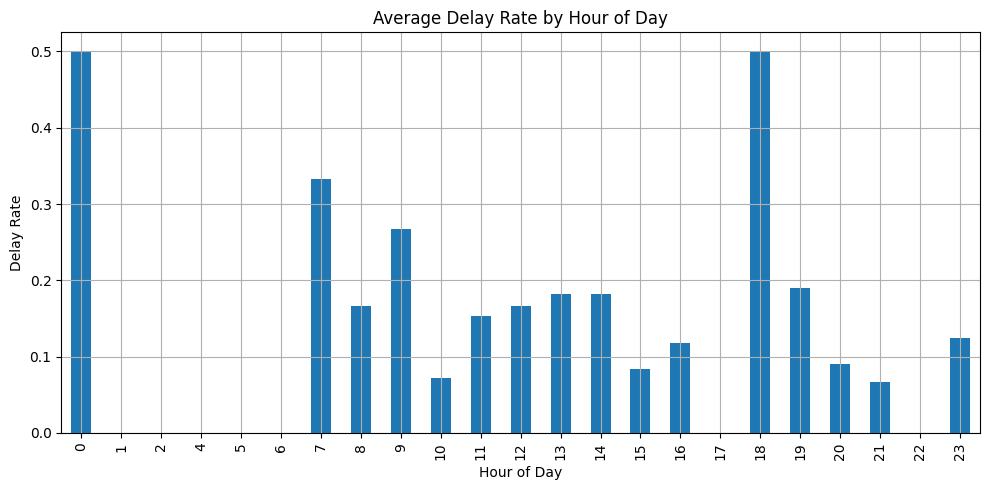

In [27]:
# Delay Rate by Hour of Day
df["hour"] = pd.to_datetime(df["arrival_time"]).dt.hour
delay_by_hour = df.groupby("hour")["delayed"].mean()

delay_by_hour.plot(kind="bar", figsize=(10, 5), title="Average Delay Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Delay Rate")
plt.grid(True)
plt.tight_layout()
plt.show()
